# Credit Union Partnership Growth Strategy Analysis
### A Data-Driven Opportunity Scorecard — For to University Credit Union (UCU)

**By:** Pranav Piedy | UCLA Anderson MSBA '26  
**Date:** March 2026  
**Data Sources:** IPEDS Fall Enrollment (EF), IPEDS Employees (EAP), U.S. Census Bureau

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(12,6),'font.family':'sans-serif',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})

C = {'navy':'#1B365D','teal':'#0891B2','gold':'#F59E0B','green':'#10B981',
     'red':'#EF4444','purple':'#8B5CF6','text':'#1E293B','muted':'#64748B'}

In [4]:
#CONFIG
DATA_DIR = 'D:/Pranav/UCLA/Internships/UCU/data/final_data/'   
VIS_DIR  = './visuals/' 
os.makedirs(VIS_DIR, exist_ok=True)

# UCU Partner Schools — IPEDS UNITIDs
PARTNERS = {
    110662: {'name':'UCLA','state':'CA','type':'Public R1','joined':1951,'conf':'Founding'},
    121150: {'name':'Pepperdine University','state':'CA','type':'Private','joined':2010,'conf':'WCC'},
    117946: {'name':'Loyola Marymount University','state':'CA','type':'Private','joined':2012,'conf':'WCC'},
    122931: {'name':'Santa Clara University','state':'CA','type':'Private','joined':2015,'conf':'WCC'},
    113698: {'name':"Saint Mary's College of CA",'state':'CA','type':'Private','joined':2024,'conf':'WCC'},
    110653: {'name':'UC Irvine','state':'CA','type':'Public R1','joined':2018,'conf':'UC System'},
    110644: {'name':'UC Davis','state':'CA','type':'Public R1','joined':2019,'conf':'UC System'},
    110680: {'name':'UC San Diego','state':'CA','type':'Public R1','joined':2020,'conf':'UC System'},
    139755: {'name':'Georgia Tech','state':'GA','type':'Public R1','joined':2021,'conf':'Out-of-State'},
    228769: {'name':'UT Arlington','state':'TX','type':'Public R1','joined':2024,'conf':'Out-of-State'},
    222178: {'name':'Abilene Christian University','state':'TX','type':'Private','joined':2025,'conf':'WAC'},
    118684: {'name':"Mount Saint Mary's University",'state':'CA','type':'Private','joined':2016,'conf':'LA Local'},
    112826: {'name':'Chabot College','state':'CA','type':'Community College','joined':2014,'conf':'CC'},
    118888: {'name':'Las Positas College','state':'CA','type':'Community College','joined':2014,'conf':'CC'},
}
PARTNER_IDS = list(PARTNERS.keys())
YEARS = list(range(2019, 2025))

# Census data (median household income by campus metro)
CENSUS = {
    'UCLA':82000,'Pepperdine University':82000,'Loyola Marymount University':82000,
    "Mount Saint Mary's University":82000,'Santa Clara University':133000,
    "Saint Mary's College of CA":120000,'UC Irvine':82000,'UC Davis':78000,
    'UC San Diego':85000,'Georgia Tech':75000,'UT Arlington':72000,
    'Abilene Christian University':52000,'Chabot College':120000,'Las Positas College':120000,
}
print(f'Config: {len(PARTNERS)} schools, {YEARS[0]}-{YEARS[-1]}')

Config: 14 schools, 2019-2024


## 2. Data Ingestion & Cleaning

**Source files:**
- `ef{YEAR}a.csv` / `ef{YEAR}a_rv.csv` — Fall Enrollment (all US institutions)
- `eap{YEAR}.csv` / `eap{YEAR}_rv.csv` — Employees by Assigned Position (all US institutions)

**Filters applied:**
- Enrollment: `EFALEVEL == 1` → All students total
- Employees: `EAPCAT == 10000` → All staff total
- Both filtered to UCU partner UNITIDs only

In [5]:
# ============================================================
# LOAD FALL ENROLLMENT (2019-2024)
# File convention: 2024=ef2024a.csv, 2019-2023=ef{year}a_rv.csv
# ============================================================
enroll_frames = []
for year in YEARS:
    fname = f'{DATA_DIR}ef{year}a.csv' if year == 2024 else f'{DATA_DIR}ef{year}a_rv.csv'
    try:
        df = pd.read_csv(fname, encoding='latin-1')
        df = df[(df['EFALEVEL']==1) & (df['UNITID'].isin(PARTNER_IDS))][['UNITID','EFTOTLT','EFTOTLM','EFTOTLW']].copy()
        for c in ['EFTOTLT','EFTOTLM','EFTOTLW']: df[c] = pd.to_numeric(df[c], errors='coerce')
        df['year'] = year
        enroll_frames.append(df)
        print(f'  {year}: {len(df)} schools | {os.path.basename(fname)}')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND - {fname}')

enrollment = pd.concat(enroll_frames, ignore_index=True)
enrollment.rename(columns={'UNITID':'unitid','EFTOTLT':'total_enrollment',
                           'EFTOTLM':'enrollment_men','EFTOTLW':'enrollment_women'}, inplace=True)
enrollment['institution_name'] = enrollment['unitid'].map({k:v['name'] for k,v in PARTNERS.items()})
print(f'\nEnrollment: {len(enrollment)} rows ({enrollment["unitid"].nunique()} schools x {enrollment["year"].nunique()} years)')

  2019: 14 schools | ef2019a_rv.csv
  2020: 14 schools | ef2020a_rv.csv
  2021: 14 schools | ef2021a_rv.csv
  2022: 13 schools | ef2022a_rv.csv
  2023: 14 schools | ef2023a_rv.csv
  2024: 14 schools | ef2024a.csv

Enrollment: 83 rows (14 schools x 6 years)


In [6]:
# ============================================================
# LOAD EMPLOYEE DATA (2019-2024)
# File convention: 2024=eap2024.csv, 2019-2023=eap{year}_rv.csv
# Filter: EAPCAT==10000 ("All staff" top-level total)
# ============================================================
emp_frames = []
for year in YEARS:
    fname = f'{DATA_DIR}eap{year}.csv' if year == 2024 else f'{DATA_DIR}eap{year}_rv.csv'
    try:
        df = pd.read_csv(fname, encoding='latin-1')
        df = df[(df['EAPCAT']==10000) & (df['UNITID'].isin(PARTNER_IDS))][['UNITID','EAPTOT','EAPFT','EAPPT']].copy()
        for c in ['EAPTOT','EAPFT','EAPPT']: df[c] = pd.to_numeric(df[c], errors='coerce')
        df['year'] = year
        emp_frames.append(df)
        print(f'  {year}: {len(df)} schools | {os.path.basename(fname)}')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND - {fname}')

employees = pd.concat(emp_frames, ignore_index=True)
employees.rename(columns={'UNITID':'unitid','EAPTOT':'total_employees',
                          'EAPFT':'ft_employees','EAPPT':'pt_employees'}, inplace=True)
employees['institution_name'] = employees['unitid'].map({k:v['name'] for k,v in PARTNERS.items()})
print(f'\nEmployees: {len(employees)} rows ({employees["unitid"].nunique()} schools x {employees["year"].nunique()} years)')

  2019: 14 schools | eap2019_rv.csv
  2020: 14 schools | eap2020_rv.csv
  2021: 14 schools | eap2021_rv.csv
  2022: 13 schools | eap2022_rv.csv
  2023: 14 schools | eap2023_rv.csv
  2024: 14 schools | eap2024.csv

Employees: 83 rows (14 schools x 6 years)


In [7]:
# ============================================================
# MERGE INTO MASTER DATASET
# ============================================================
master = enrollment.merge(employees[['unitid','year','total_employees','ft_employees','pt_employees']],
                          on=['unitid','year'], how='left')

# Add partnership metadata
for uid, info in PARTNERS.items():
    m = master['unitid']==uid
    for k in ['state','type','joined','conf']:
        col = {'type':'institution_type','joined':'year_joined_ucu','conf':'conference'}.get(k,k)
        master.loc[m, col] = info[k]

# Add census income
master['median_income'] = master['institution_name'].map(CENSUS)

# Derived columns
master['total_addressable_pop'] = master['total_enrollment'] + master['total_employees'].fillna(0)
master['partnership_age'] = (master['year'] - master['year_joined_ucu']).clip(lower=0)
master['pct_women'] = (master['enrollment_women'] / master['total_enrollment'] * 100).round(1)
master['ft_pct'] = (master['ft_employees'] / master['total_employees'] * 100).round(1)
master = master.sort_values(['unitid','year'])
master['enrollment_yoy'] = master.groupby('unitid')['total_enrollment'].pct_change() * 100

print(f'Master: {len(master)} rows x {len(master.columns)} cols')
print(f'Nulls in key columns:\n{master[["total_enrollment","total_employees"]].isnull().sum()}')

Master: 83 rows x 19 cols
Nulls in key columns:
total_enrollment    0
total_employees     0
dtype: int64


## 3. Validation & Summary

In [8]:
# Validate UCLA 2024
ucla = master[(master['institution_name']=='UCLA') & (master['year']==2024)]
print('=== UCLA 2024 VALIDATION ===')
print(f'  Enrollment: {ucla["total_enrollment"].values[0]:,.0f}')
print(f'  Employees:  {ucla["total_employees"].values[0]:,.0f}')
print(f'  TAM:        {ucla["total_addressable_pop"].values[0]:,.0f}')

# All schools 2024
latest = master[master['year']==2024].sort_values('total_addressable_pop', ascending=False)
total_tam = latest['total_addressable_pop'].sum()
print(f'\n=== ALL PARTNERS 2024 ===')
for _, r in latest.iterrows():
    print(f'  {r["institution_name"]:35s} Enroll: {r["total_enrollment"]:>7,.0f}  Staff: {r["total_employees"]:>7,.0f}  TAM: {r["total_addressable_pop"]:>8,.0f}')
print(f'\n  TOTAL ADDRESSABLE MARKET: {total_tam:,.0f}')

=== UCLA 2024 VALIDATION ===
  Enrollment: 47,335
  Employees:  30,136
  TAM:        77,471

=== ALL PARTNERS 2024 ===
  UCLA                                Enroll:  47,335  Staff:  30,136  TAM:   77,471
  Georgia Tech                        Enroll:  53,363  Staff:  10,954  TAM:   64,317
  UC San Diego                        Enroll:  44,256  Staff:  19,504  TAM:   63,760
  UC Davis                            Enroll:  40,065  Staff:  15,029  TAM:   55,094
  UT Arlington                        Enroll:  44,956  Staff:   4,658  TAM:   49,614
  UC Irvine                           Enroll:  37,297  Staff:  10,206  TAM:   47,503
  Loyola Marymount University         Enroll:  10,179  Staff:   2,639  TAM:   12,818
  Santa Clara University              Enroll:   9,728  Staff:   2,103  TAM:   11,831
  Pepperdine University               Enroll:   8,976  Staff:   2,165  TAM:   11,141
  Chabot College                      Enroll:   6,538  Staff:     417  TAM:    6,955
  Abilene Christian University 

## 4. Exploratory Analysis

In [21]:
latest.head(10)

,unitid,total_enrollment,enrollment_men,enrollment_women,year,institution_name,total_employees,ft_employees,pt_employees,state,institution_type,year_joined_ucu,conference,median_income,total_addressable_pop,partnership_age,pct_women,ft_pct,enrollment_yoy
71,110662,47335,20430,26905,2024,UCLA,30136,27786.0,2350.0,CA,Public R1,1951.0,Founding,82000,77471,73.0,56.8,92.2,1.407515
80,139755,53363,36169,17194,2024,Georgia Tech,10954,9903.0,1051.0,GA,Public R1,2021.0,Out-of-State,75000,64317,3.0,32.2,90.4,11.298127
72,110680,44256,20975,23281,2024,UC San Diego,19504,17690.0,1814.0,CA,Public R1,2020.0,UC System,85000,63760,4.0,52.6,90.7,4.436473
69,110644,40065,16798,23267,2024,UC Davis,15029,13687.0,1342.0,CA,Public R1,2019.0,UC System,78000,55094,5.0,58.1,91.1,0.901604
82,228769,44956,17909,27047,2024,UT Arlington,4658,3889.0,769.0,TX,Public R1,2024.0,Out-of-State,72000,49614,0.0,60.2,83.5,2.191308
70,110653,37297,16711,20586,2024,UC Irvine,10206,9258.0,948.0,CA,Public R1,2018.0,UC System,82000,47503,6.0,55.2,90.7,1.954513
75,117946,10179,4592,5587,2024,Loyola Marymount University,2639,2064.0,575.0,CA,Private,2012.0,WCC,82000,12818,12.0,54.9,78.2,-0.750780
79,122931,9728,4719,5009,2024,Santa Clara University,2103,1795.0,308.0,CA,Private,2015.0,WCC,133000,11831,9.0,51.5,85.4,4.154176
78,121150,8976,2983,5993,2024,Pepperdine University,2165,1620.0,545.0,CA,Private,2010.0,WCC,82000,11141,14.0,66.8,74.8,-5.961236
73,112826,6538,2628,3910,2024,Chabot College,417,240.0,177.0,CA,Community College,2014.0,CC,120000,6955,10.0,59.8,57.6,9.021177


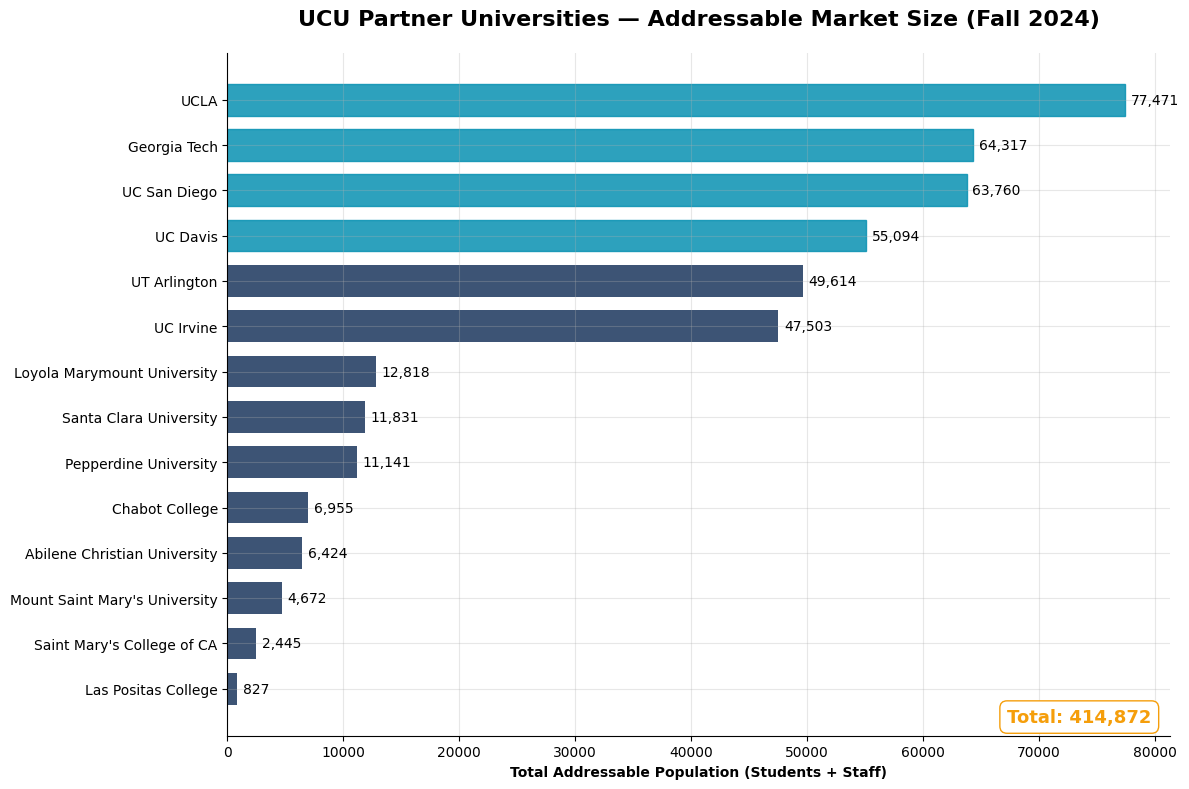

In [9]:
# CHART 1: Addressable Market (2024)
ls = latest.sort_values('total_addressable_pop', ascending=True)
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(ls['institution_name'], ls['total_addressable_pop'], color=C['navy'], alpha=0.85, height=0.7)
q75 = ls['total_addressable_pop'].quantile(0.75)
for bar in bars:
    if bar.get_width() > q75: bar.set_color(C['teal'])
    ax.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2, f'{bar.get_width():,.0f}', va='center', fontsize=10)
ax.set_xlabel('Total Addressable Population (Students + Staff)', fontweight='bold')
ax.set_title('UCU Partner Universities — Addressable Market Size (Fall 2024)', fontweight='bold', fontsize=16, pad=20)
ax.annotate(f'Total: {total_tam:,.0f}', xy=(0.98,0.02), xycoords='axes fraction', ha='right', fontsize=13,
            fontweight='bold', color=C['gold'], bbox=dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor=C['gold']))
plt.tight_layout(); plt.savefig(f'{VIS_DIR}01_addressable_market.png', dpi=150, bbox_inches='tight'); plt.show()

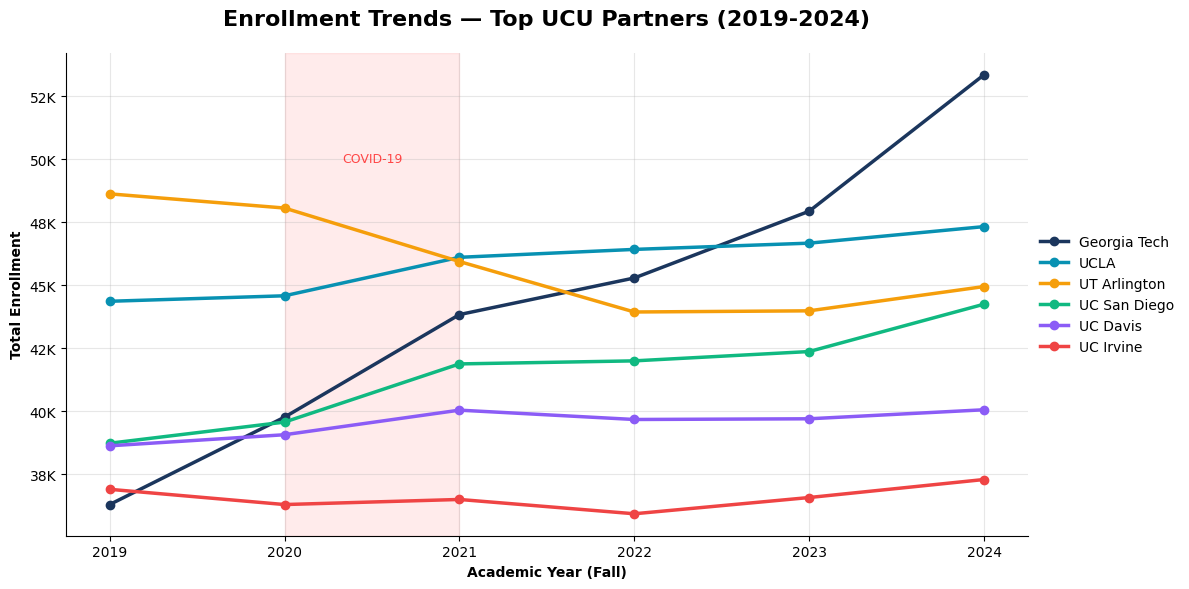

In [19]:
# CHART 2: Enrollment Trends (2019-2024)
top6 = latest.nlargest(6,'total_enrollment')['institution_name'].values
cl = [C['navy'],C['teal'],C['gold'],C['green'],C['purple'],C['red']]
fig, ax = plt.subplots(figsize=(12,6))
for i, s in enumerate(top6):
    sd = master[master['institution_name']==s].sort_values('year')
    ax.plot(sd['year'], sd['total_enrollment'], marker='o', linewidth=2.5, label=s, color=cl[i], markersize=6)
ax.set_xlabel('Academic Year (Fall)', fontweight='bold')
ax.set_ylabel('Total Enrollment', fontweight='bold')
ax.set_title('Enrollment Trends — Top UCU Partners (2019-2024)', fontweight='bold', fontsize=16, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
ax.axvspan(2020,2021, alpha=0.08, color='red')
ax.annotate('COVID-19', xy=(2020.5, ax.get_ylim()[1]*0.92), ha='center', fontsize=9, color='red', alpha=0.7)
plt.tight_layout(); plt.savefig(f'{VIS_DIR}02_enrollment_trends.png', dpi=150, bbox_inches='tight'); plt.show()

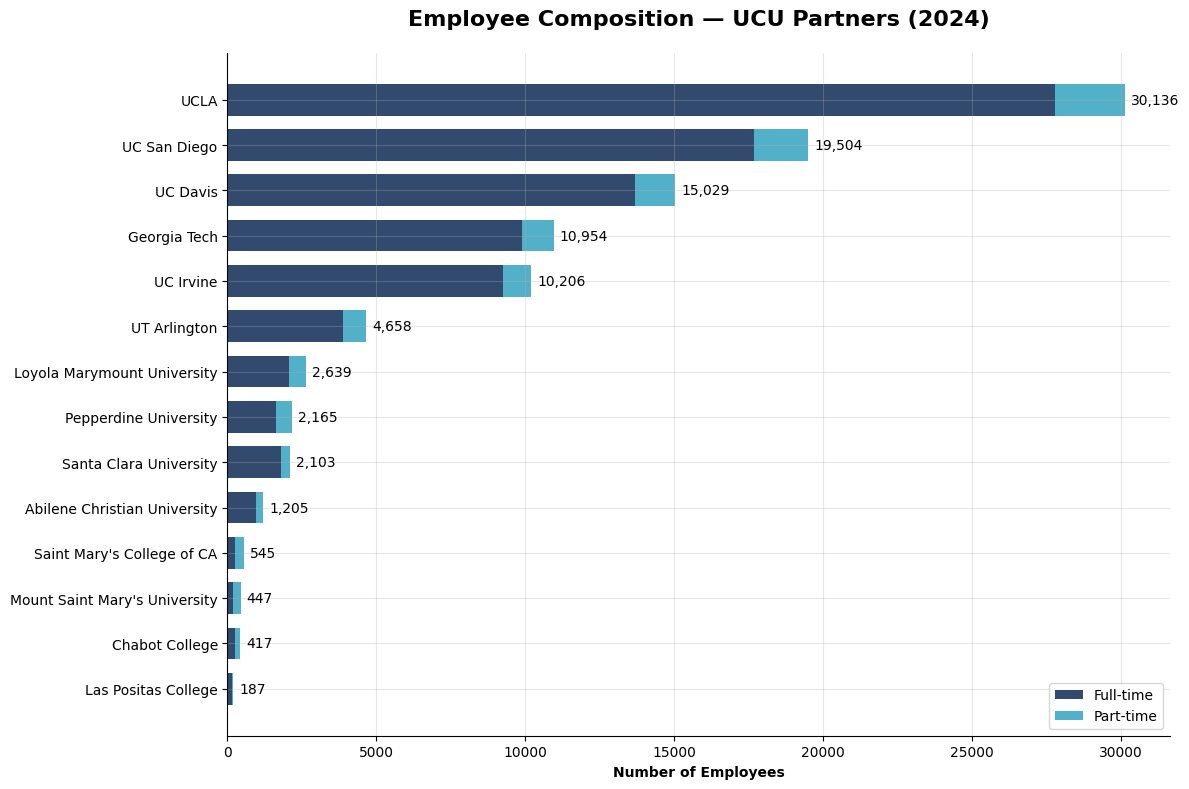

In [11]:
# CHART 3: Employee Composition FT vs PT (2024)
e24 = latest[['institution_name','ft_employees','pt_employees','total_employees']].dropna().sort_values('total_employees', ascending=True)
fig, ax = plt.subplots(figsize=(12,8))
ax.barh(e24['institution_name'], e24['ft_employees'], color=C['navy'], alpha=0.9, label='Full-time', height=0.7)
ax.barh(e24['institution_name'], e24['pt_employees'], left=e24['ft_employees'], color=C['teal'], alpha=0.7, label='Part-time', height=0.7)
for i, (_,row) in enumerate(e24.iterrows()):
    ax.text(row['total_employees']+200, i, f'{row["total_employees"]:,.0f}', va='center', fontsize=10)
ax.set_xlabel('Number of Employees', fontweight='bold')
ax.set_title('Employee Composition — UCU Partners (2024)', fontweight='bold', fontsize=16, pad=20)
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}03_employee_composition.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Partnership Opportunity Scorecard

In [13]:
# BUILD SCORECARD
sc = latest[['institution_name','unitid','total_addressable_pop','total_enrollment','total_employees',
             'ft_employees','pt_employees','enrollment_yoy','median_income','year_joined_ucu',
             'partnership_age','conference','institution_type','state','pct_women']].copy()

def norm(s):
    r = s.max()-s.min()
    return pd.Series(50, index=s.index) if r==0 else ((s-s.min())/r*100).fillna(0)

sc['size_score']      = norm(sc['total_addressable_pop'])
sc['growth_score']    = norm(sc['enrollment_yoy'].fillna(0))
sc['need_score']      = norm(sc['median_income'].max() - sc['median_income'])
sc['freshness_score'] = norm(sc['partnership_age'].max() - sc['partnership_age'])

sc['opportunity_score'] = sc['size_score']*0.4 + sc['growth_score']*0.2 + sc['need_score']*0.2 + sc['freshness_score']*0.2
sc = sc.sort_values('opportunity_score', ascending=False)
sc['tier'] = pd.cut(sc['opportunity_score'], bins=[-1,33,66,101], labels=['Tier 3: Maintain','Tier 2: Grow','Tier 1: Prioritize'])

print('=== OPPORTUNITY SCORECARD ===')
for _, r in sc.iterrows():
    print(f'  {r["institution_name"]:35s} Score:{r["opportunity_score"]:5.1f}  TAM:{r["total_addressable_pop"]:>8,.0f}  [{r["tier"]}]')

=== OPPORTUNITY SCORECARD ===
  Georgia Tech                        Score: 86.6  TAM:  64,317  [Tier 1: Prioritize]
  UC San Diego                        Score: 75.8  TAM:  63,760  [Tier 1: Prioritize]
  UT Arlington                        Score: 70.1  TAM:  49,614  [Tier 1: Prioritize]
  UC Davis                            Score: 68.7  TAM:  55,094  [Tier 1: Prioritize]
  UC Irvine                           Score: 64.6  TAM:  47,503  [Tier 2: Grow]
  UCLA                                Score: 61.3  TAM:  77,471  [Tier 2: Grow]
  Abilene Christian University        Score: 52.4  TAM:   6,424  [Tier 2: Grow]
  Mount Saint Mary's University       Score: 45.0  TAM:   4,672  [Tier 2: Grow]
  Loyola Marymount University         Score: 41.8  TAM:  12,818  [Tier 2: Grow]
  Chabot College                      Score: 41.1  TAM:   6,955  [Tier 2: Grow]
  Santa Clara University              Score: 35.1  TAM:  11,831  [Tier 2: Grow]
  Pepperdine University               Score: 34.4  TAM:  11,141  [

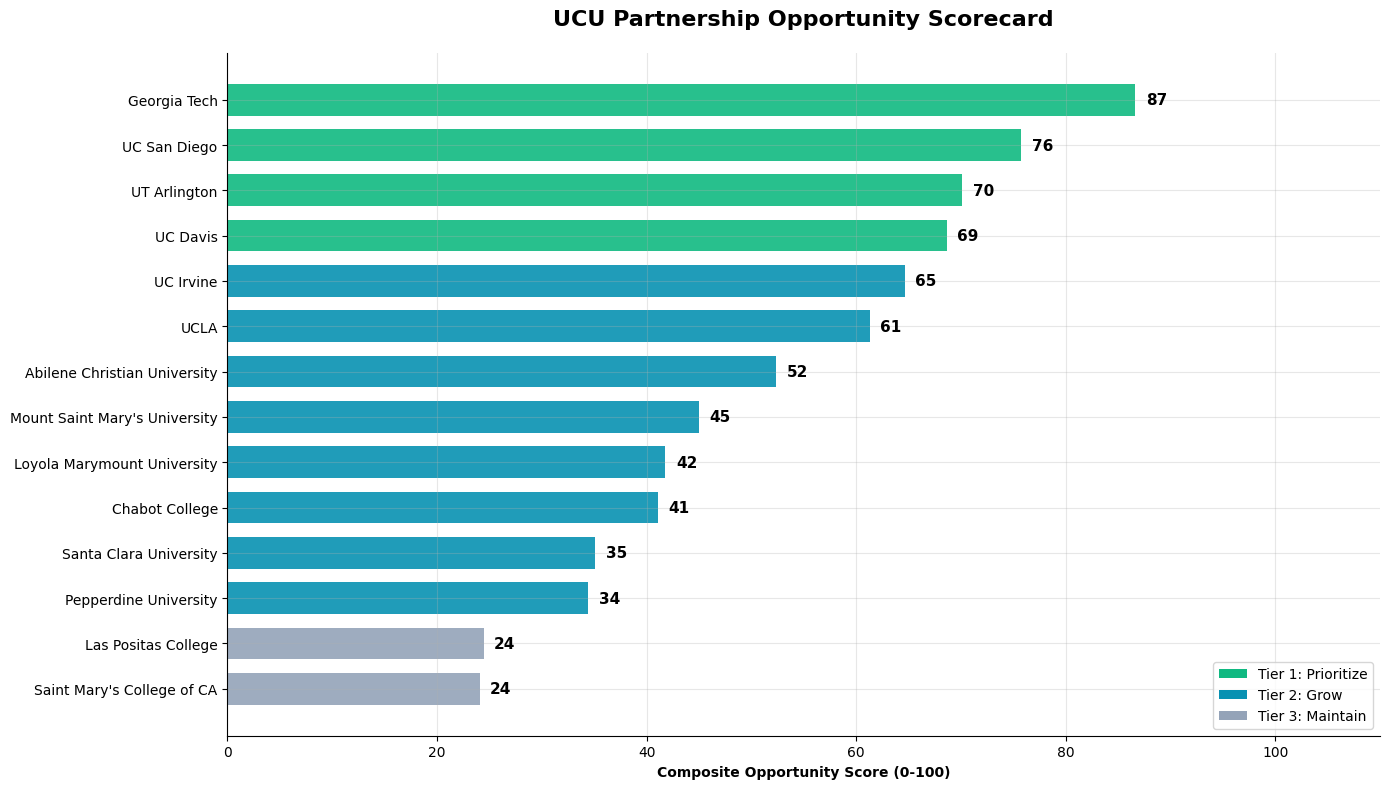

In [14]:
# CHART 4: Scorecard
ss = sc.sort_values('opportunity_score', ascending=True)
tc = {'Tier 1: Prioritize':C['green'],'Tier 2: Grow':C['teal'],'Tier 3: Maintain':'#94A3B8'}
bc = [tc.get(str(t),'#94A3B8') for t in ss['tier']]
fig, ax = plt.subplots(figsize=(14,8))
bars = ax.barh(ss['institution_name'], ss['opportunity_score'], color=bc, height=0.7, alpha=0.9)
for bar, s in zip(bars, ss['opportunity_score']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'{s:.0f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Composite Opportunity Score (0-100)', fontweight='bold')
ax.set_title('UCU Partnership Opportunity Scorecard', fontweight='bold', fontsize=16, pad=20)
ax.set_xlim(0,110)
ax.legend(handles=[Patch(facecolor=C['green'],label='Tier 1: Prioritize'),
                   Patch(facecolor=C['teal'],label='Tier 2: Grow'),
                   Patch(facecolor='#94A3B8',label='Tier 3: Maintain')], loc='lower right')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}04_opportunity_scorecard.png', dpi=150, bbox_inches='tight'); plt.show()

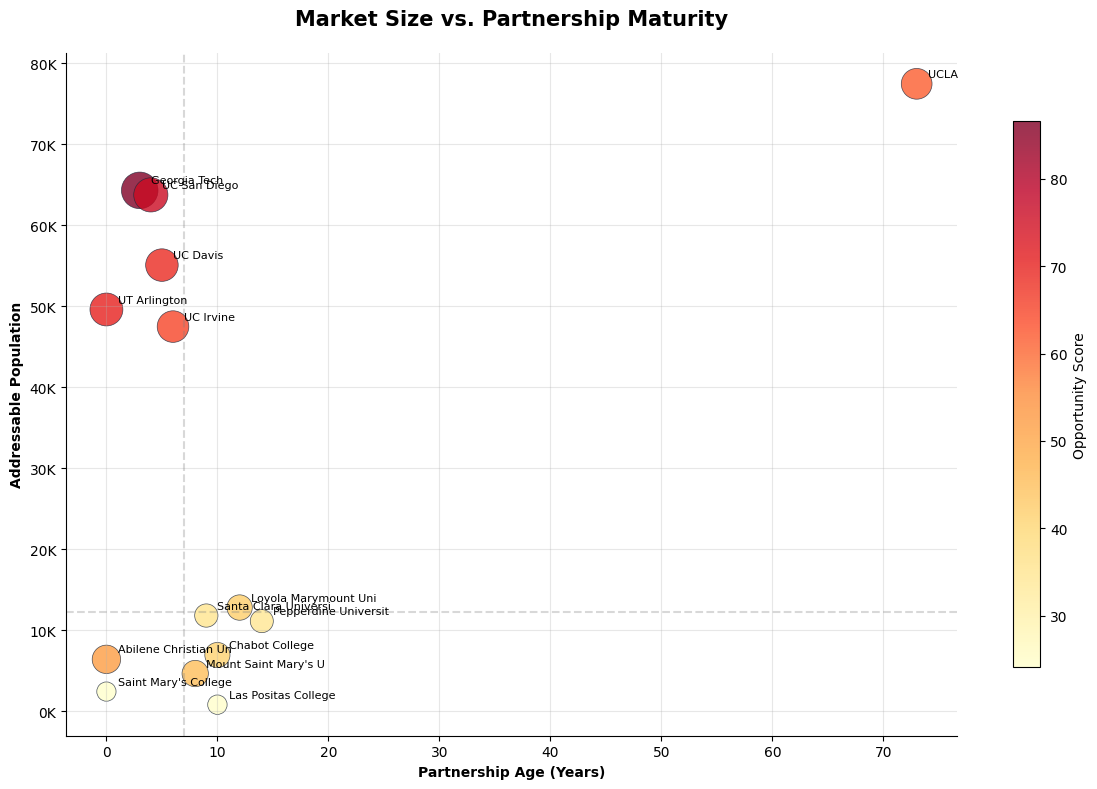

In [15]:
# CHART 5: Scatter — Market Size vs Partnership Age
fig, ax = plt.subplots(figsize=(12,8))
scat = ax.scatter(sc['partnership_age'], sc['total_addressable_pop'], s=sc['opportunity_score']*8,
                  c=sc['opportunity_score'], cmap='YlOrRd', alpha=0.8, edgecolors=C['text'], linewidths=0.5)
for _, r in sc.iterrows():
    ax.annotate(r['institution_name'][:20], (r['partnership_age'],r['total_addressable_pop']),
                textcoords='offset points', xytext=(8,5), fontsize=8)
ax.set_xlabel('Partnership Age (Years)', fontweight='bold')
ax.set_ylabel('Addressable Population', fontweight='bold')
ax.set_title('Market Size vs. Partnership Maturity', fontweight='bold', fontsize=15, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.axhline(y=sc['total_addressable_pop'].median(), color='gray', ls='--', alpha=0.3)
ax.axvline(x=sc['partnership_age'].median(), color='gray', ls='--', alpha=0.3)
plt.colorbar(scat, ax=ax, shrink=0.8, label='Opportunity Score')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}05_scatter_opportunity.png', dpi=150, bbox_inches='tight'); plt.show()

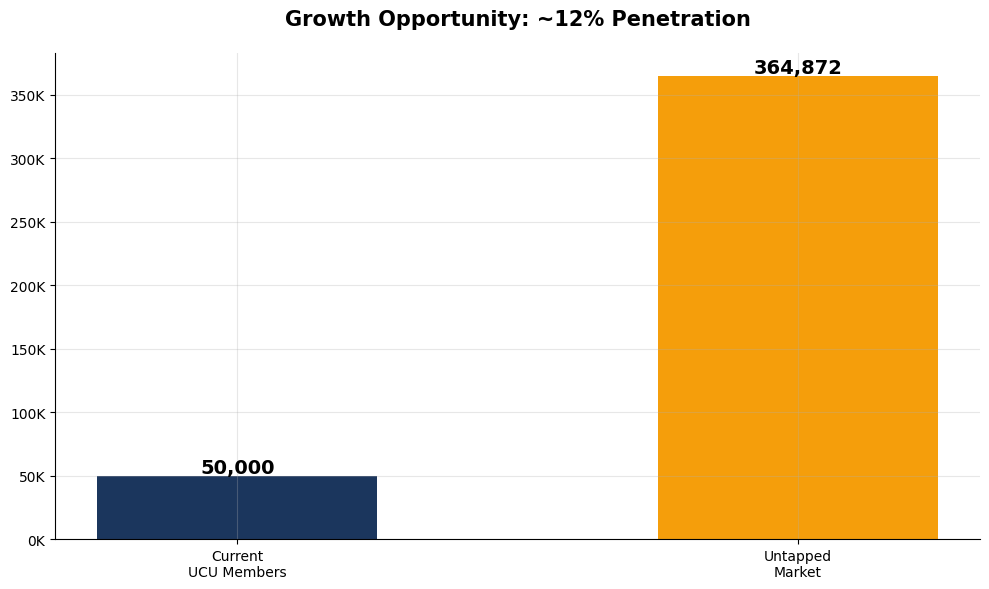

In [16]:
# CHART 6: Penetration Gap
ucu_members = 50000  # From NCUA data — update with real figure
fig, ax = plt.subplots(figsize=(10,6))
vals = [ucu_members, total_tam - ucu_members]
bars = ax.bar(['Current\nUCU Members','Untapped\nMarket'], vals, color=[C['navy'],C['gold']], width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000, f'{val:,.0f}', ha='center', fontweight='bold', fontsize=14)
pen = ucu_members/total_tam*100
ax.set_title(f'Growth Opportunity: ~{pen:.0f}% Penetration', fontweight='bold', fontsize=15, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.savefig(f'{VIS_DIR}06_penetration_gap.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. Strategic Summary

In [17]:
print('='*70)
for tn in ['Tier 1: Prioritize','Tier 2: Grow','Tier 3: Maintain']:
    td = sc[sc['tier']==tn]
    e = {'Tier 1: Prioritize':'\U0001f7e2','Tier 2: Grow':'\U0001f535','Tier 3: Maintain':'\u26aa'}[tn]
    print(f'\n{e} {tn.upper()} ({len(td)} schools) — TAM: {td["total_addressable_pop"].sum():,.0f}')
    for _,r in td.iterrows():
        print(f'   {r["institution_name"]:35s} Score:{r["opportunity_score"]:5.1f}  TAM:{r["total_addressable_pop"]:>8,.0f}  Age:{r["partnership_age"]:.0f}yr')

print(f'\n{"="*70}')
print(f'Total TAM: {total_tam:,.0f} | Members: {ucu_members:,.0f} | Penetration: {pen:.1f}%')
print(f'5pt increase = ~{total_tam*0.05:,.0f} new members')
print('='*70)


🟢 TIER 1: PRIORITIZE (4 schools) — TAM: 232,785
   Georgia Tech                        Score: 86.6  TAM:  64,317  Age:3yr
   UC San Diego                        Score: 75.8  TAM:  63,760  Age:4yr
   UT Arlington                        Score: 70.1  TAM:  49,614  Age:0yr
   UC Davis                            Score: 68.7  TAM:  55,094  Age:5yr

🔵 TIER 2: GROW (8 schools) — TAM: 178,815
   UC Irvine                           Score: 64.6  TAM:  47,503  Age:6yr
   UCLA                                Score: 61.3  TAM:  77,471  Age:73yr
   Abilene Christian University        Score: 52.4  TAM:   6,424  Age:0yr
   Mount Saint Mary's University       Score: 45.0  TAM:   4,672  Age:8yr
   Loyola Marymount University         Score: 41.8  TAM:  12,818  Age:12yr
   Chabot College                      Score: 41.1  TAM:   6,955  Age:10yr
   Santa Clara University              Score: 35.1  TAM:  11,831  Age:9yr
   Pepperdine University               Score: 34.4  TAM:  11,141  Age:14yr

⚪ TIER 3: MAINT

In [ ]:
# ============================================================
# EXPORT FOR DASHBOARD
# ============================================================
# For React dashboard deployed via GitHub Pages:
#   Save JSON to: <react-app>/public/data/opportunity_scorecard.json
#   Fetch in React: fetch('/data/opportunity_scorecard.json')
#
# For local development:
#   Save to: ./data/opportunity_scorecard.json

sc.to_csv(f'{DATA_DIR}opportunity_scorecard.csv', index=False)
sc.to_json(f'{DATA_DIR}opportunity_scorecard.json', orient='records', indent=2)

trends = master[['institution_name','year','total_enrollment','total_employees','total_addressable_pop']].copy()
trends.to_json(f'{DATA_DIR}enrollment_trends.json', orient='records', indent=2)
trends.to_csv(f'{DATA_DIR}enrollment_trends.csv', index=False)

print(f'Exported: scorecard ({len(sc)} schools), trends ({len(trends)} rows)')
print(f'Files: {DATA_DIR}opportunity_scorecard.[csv|json], {DATA_DIR}enrollment_trends.[csv|json]')

## 7. Scaling Proposal — 6-Week Delivery Plan

**Week 1-2: Data Infrastructure** — Connect internal membership DB, build ETL merging internal + IPEDS/NCUA, document data model.

**Week 3-4: Analysis & Dashboards** — Calculate actual penetration per school, build product adoption funnels, identify enrollment-cycle seasonality, create self-refreshing dashboard.

**Week 5-6: Strategic Handoff** — Executive report, documented pipelines, prioritized recommendations for leadership.

**Impact:** A 5-point penetration increase = significant new member-owners → deposit growth, loan originations, community impact.